In [26]:
import pandas as pd
from sklearn.datasets import load_iris

In [27]:
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df['target'] = iris.target
df['species'] = df['target'].map({0:'setosa', 1:'versicolor', 2:'virginica'})
df


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,virginica
146,6.3,2.5,5.0,1.9,2,virginica
147,6.5,3.0,5.2,2.0,2,virginica
148,6.2,3.4,5.4,2.3,2,virginica


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   target             150 non-null    int64  
 5   species            150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [29]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

In [30]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [31]:
df.value_counts()

sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  target  species  
5.8                2.7               5.1                1.9               2       virginica    2
4.4                2.9               1.4                0.2               0       setosa       1
                   3.0               1.3                0.2               0       setosa       1
                   3.2               1.3                0.2               0       setosa       1
4.3                3.0               1.1                0.1               0       setosa       1
                                                                                              ..
7.7                2.6               6.9                2.3               2       virginica    1
                   2.8               6.7                2.0               2       virginica    1
                   3.0               6.1                2.3               2       virginica    1
                   3.8             

In [32]:
df[['species']].value_counts()

species   
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

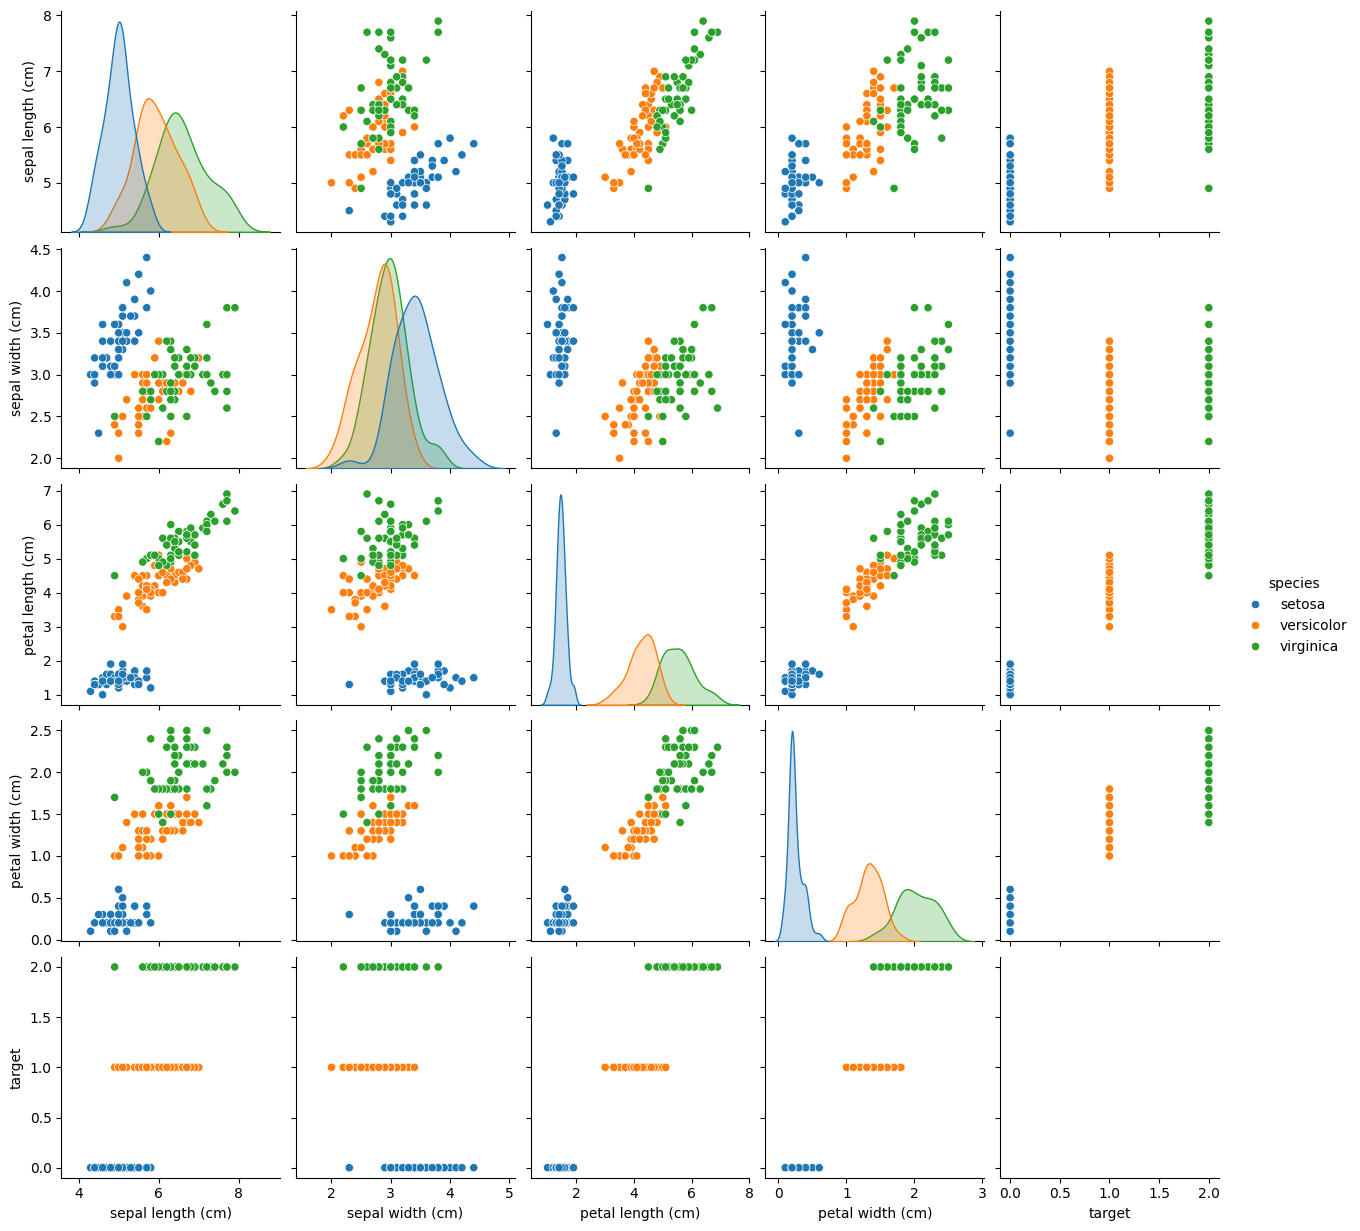

In [33]:
import seaborn as sns
sns.pairplot(df, hue='species')

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression



In [35]:
y = df['target']
X = df.drop(columns = ['target','species'])
X_train,X_test,y_train,y_test = train_test_split(X , y , test_size=0.3, random_state=42, stratify=y)

In [36]:
model = LogisticRegression()
model.fit(X_train,y_train)

c:\Users\bigge\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [37]:
y_predict = model.predict(X_test)

In [38]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_predict)
print("--- Classification Results ---")
print(f"Accuracy: {accuracy:.2f}")

--- Classification Results ---
Accuracy: 0.93


In [39]:
import seaborn as sns


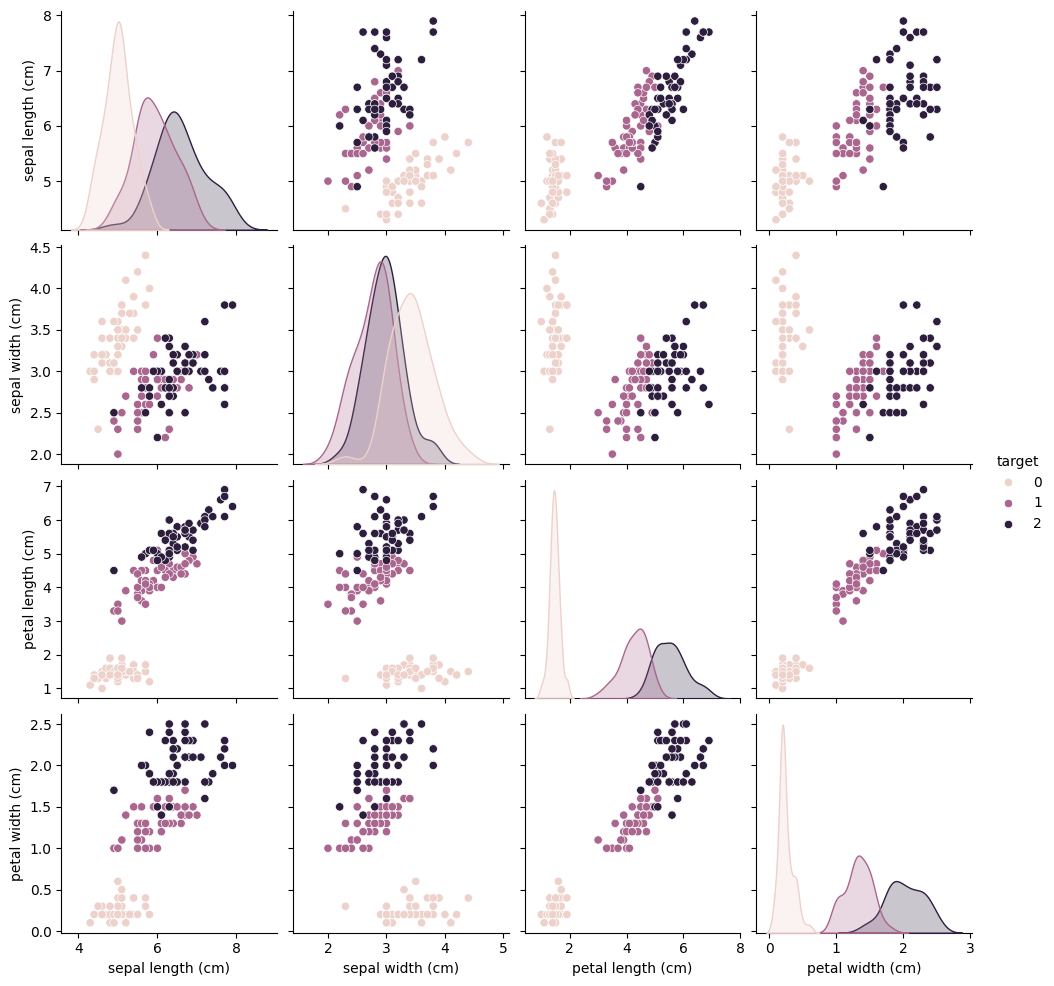

In [40]:
sns.pairplot(df, hue='target')

In [41]:
from sklearn.neighbors import KNeighborsClassifier

In [42]:
knn = KNeighborsClassifier(3)
knn.fit(X_train, y_train)
knn_y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, knn_y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.93


In [43]:
from sklearn.svm import SVC

In [44]:
svc = SVC()
svc.fit(X_train,y_train)
SVC_Y_PRED = svc.predict(X_test)
accuracy = accuracy_score(y_test, SVC_Y_PRED)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.96


In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [46]:
accuracy = accuracy_score(y_test, y_predict)
precision = precision_score(y_test, y_predict, average = 'micro')
recall = recall_score(y_test, y_predict, average = 'micro')
f1 = f1_score(y_test, y_predict, average = 'micro')
print("Accuracy: ", accuracy)
print("Precision: ", precision)
print("Recall: ", recall)
print("F1-Score: ", f1)
print(classification_report(y_test, y_predict))

Accuracy:  0.9333333333333333
Precision:  0.9333333333333333
Recall:  0.9333333333333333
F1-Score:  0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       0.88      0.93      0.90        15
           2       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45



In [47]:
from sklearn.tree import DecisionTreeRegressor

In [48]:
tree_model = DecisionTreeRegressor(max_depth=10, random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report


In [50]:
accuracy = accuracy_score(y_test, y_pred_tree)
precision = precision_score(y_test, y_pred_tree, average = 'micro')
recall = recall_score(y_test, y_pred_tree, average = 'micro')
f1 = f1_score(y_test, y_pred_tree, average = 'micro')
print(f"Accuracy: ", accuracy)
print(f"Precision: ", precision)
print(f"Recall: ", recall)
print(f"F1-Score: ", f1)
print(classification_report(y_test, y_pred_tree))

Accuracy:  0.9333333333333333
Precision:  0.9333333333333333
Recall:  0.9333333333333333
F1-Score:  0.9333333333333333
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        15
           1       1.00      0.80      0.89        15
           2       0.83      1.00      0.91        15

    accuracy                           0.93        45
   macro avg       0.94      0.93      0.93        45
weighted avg       0.94      0.93      0.93        45

